## 1. Imports

In [1]:
import re
import nltk
import requests
import time
import json

import numpy                as np
import pandas               as pd
import plotly.express       as px
import plotly.graph_objects as go
import matplotlib.pyplot    as plt
import seaborn              as sns

from nltk.corpus import stopwords
from pathlib     import Path
from datetime    import datetime
from wordcloud   import WordCloud
from pathlib     import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay)
from sentence_transformers   import SentenceTransformer




/Users/tiagoleite/Desktop/projeto_nlp/.venv/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


## 2. Funções

In [2]:
# funçoes para coletar os dados da API

LIMITE_TOTAL_EDITAIS = 3000

def coletarEditaisModalidade(codigo_modalidade, data_inicial, data_final, limite_restante):
    #Coleta editais de uma modalidade específica, respeitando um limite máximo de registros a coletar

    editais = []
    pagina = 1
    
    while True:
        if len(editais) >= limite_restante:
            print(f"Limite de coleta atingido para esta modalidade. Parando.")
            break
        
        params = {
            "dataInicial": data_inicial,
            "dataFinal": data_final,
            "codigoModalidadeContratacao": codigo_modalidade,
            "pagina": pagina,
            "tamanhoPagina": TAMANHO_PAGINA
        }
        
        response = requests.get(BASE_URL, params=params)
        
        if response.status_code == 429:
            print(f"Rate limit atingido na página {pagina}. Esperando 5s ...")
            time.sleep(5)
            continue
        
        if response.status_code != 200:
            print(f"Erro na modalidade {codigo_modalidade}, na página {pagina}: status {response.status_code}")
            break
        
        dados = response.json()
        registros = dados.get("data", [])
        
        if not registros:
            break
        
        editais.extend(registros)
        
        total_paginas = dados.get("totalPaginas", 1)
        print(f"Modalidade {codigo_modalidade} - página {pagina}/{total_paginas} - {len(registros)} registros (acumulado: {len(editais)})")
        
        if pagina >= total_paginas:
            break
        
        pagina += 1
        time.sleep(1.5)
    
    return editais


def coletarTodasModalidades(modalidades, data_inicial, data_final, limite_total):
    #Roda a coleta para cada modalidade, parando quando o limite GLOBAL é atingido. nao vi ter um numero certo para cada modalidade, para trazer o retrato da realidade

    todos_editais = []
    
    for codigo, nome in modalidades.items():
        limite_restante = limite_total - len(todos_editais)
        
        if limite_restante <= 0:
            print(f"\nLimite total de {limite_total} já atingido. Pulando modalidade {nome}.")
            break
        
        print(f"\n- Coletando: {nome} (código {codigo}) - restam {limite_restante} para o limite total -")
        editais_modalidade = coletarEditaisModalidade(codigo, data_inicial, data_final, limite_restante)
        
        for edital in editais_modalidade:
            edital["modalidade_nome"] = nome
        
        todos_editais.extend(editais_modalidade)
        print(f"Total coletado para {nome}: {len(editais_modalidade)} | Total geral acumulado: {len(todos_editais)}")
    
    return todos_editais

In [3]:
# função para limpar e normalizar o texto 

def limparTexto(texto):
    
    if not isinstance(texto, str):
        return ""
    
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúâêîôûãõàèìòùç\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    tokens = texto.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    texto = " ".join(tokens)
    
    return texto

## 3. Coleta de dados (ELT) - API do PNCP (Potal Nascional de Contas Publicas)

In [5]:
# configuraçoes essenciais para puxar os dados certos da API

BASE_URL = "https://pncp.gov.br/api/consulta/v1/contratacoes/publicacao"
DADOS_RAW_PATH = Path("../dados/raw")
DADOS_RAW_PATH.mkdir(parents=True, exist_ok=True)

DATA_INICIAL = "20260601"
DATA_FINAL = "20260603"

MODALIDADES = {
    4: "Concorrência - Eletrônica",
    5: "Concorrência - Presencial",
    6: "Pregão - Eletrônico",
    7: "Pregão - Presencial",
    8: "Dispensa de Licitação",
    9: "Inexigibilidade"
}

TAMANHO_PAGINA = 50

In [4]:
# coletando os dados 

todos_editais = coletarTodasModalidades( modalidades=MODALIDADES,
                                        data_inicial= DATA_INICIAL,
                                        data_final= DATA_FINAL,
                                        limite_total= LIMITE_TOTAL_EDITAIS )

print(f"Total de editais coletados: {len(todos_editais)}")


- Coletando: Concorrência - Eletrônica (código 4) - restam 3000 para o limite total -
Modalidade 4 - página 1/22 - 50 registros (acumulado: 50)
Modalidade 4 - página 2/22 - 50 registros (acumulado: 100)
Modalidade 4 - página 3/22 - 50 registros (acumulado: 150)
Modalidade 4 - página 4/22 - 50 registros (acumulado: 200)
Modalidade 4 - página 5/22 - 50 registros (acumulado: 250)
Modalidade 4 - página 6/22 - 50 registros (acumulado: 300)
Modalidade 4 - página 7/22 - 50 registros (acumulado: 350)
Modalidade 4 - página 8/22 - 50 registros (acumulado: 400)
Modalidade 4 - página 9/22 - 50 registros (acumulado: 450)
Modalidade 4 - página 10/22 - 50 registros (acumulado: 500)
Modalidade 4 - página 11/22 - 50 registros (acumulado: 550)
Modalidade 4 - página 12/22 - 50 registros (acumulado: 600)
Modalidade 4 - página 13/22 - 50 registros (acumulado: 650)
Modalidade 4 - página 14/22 - 50 registros (acumulado: 700)
Modalidade 4 - página 15/22 - 50 registros (acumulado: 750)
Modalidade 4 - página 1

#### 3.1 Salvando o Dataset Bruto

In [5]:
caminho_arquivo = DADOS_RAW_PATH / "editais.json"

with open(caminho_arquivo, "w", encoding="utf-8") as f:
    json.dump(todos_editais, f, ensure_ascii=False, indent=2)

print(f"salvos {len(todos_editais)} editais em {caminho_arquivo}")


salvos 3010 editais em ../dados/raw/editais.json


#### 3.1.1 Puxando os dados Salvos


In [6]:
# para nao precisar mais chamar a API quando reiniciar o kernel
with open(DADOS_RAW_PATH / "editais.json", "r", encoding="utf-8") as f:
    todos_editais = json.load(f)

print(f"Total de editais carregados: {len(todos_editais)}")

Total de editais carregados: 3010


### 3.2 Transformando em DataFrame

In [7]:
df = pd.DataFrame(todos_editais)

# aproeitando o rotulo que ja veem para categorizar os dados
df['categoria'] = df['modalidade_nome']

print(f"total de registros {len(df)}")
print( df['categoria'].value_counts())

total de registros 3010
categoria
Pregão - Eletrônico          1900
Concorrência - Eletrônica    1060
Concorrência - Presencial      50
Name: count, dtype: int64


In [8]:
df.head()

,modalidadeId,modoDisputaId,srp,dataAtualizacao,dataInclusao,dataPublicacaoPncp,orgaoEntidade,anoCompra,sequencialCompra,numeroCompra,...,modalidadeNome,modoDisputaNome,tipoInstrumentoConvocatorioCodigo,tipoInstrumentoConvocatorioNome,fontesOrcamentarias,situacaoCompraId,situacaoCompraNome,usuarioNome,modalidade_nome,categoria
0,4,1,False,2026-06-01T00:10:40,2026-06-01T00:10:40,2026-06-01T00:10:40,"{'cnpj': '90483066000172', 'razaoSocial': 'MUN...",2026,44,0005,...,Concorrência - Eletrônica,Aberto,1,Edital,[],1,Divulgada no PNCP,PROCERGS - CENTRO DE TECNOLOGIA DA INFORMACAO ...,Concorrência - Eletrônica,Concorrência - Eletrônica
1,4,1,False,2026-06-23T13:04:32,2026-06-01T02:10:21,2026-06-01T02:10:21,"{'cnpj': '12122065000199', 'razaoSocial': 'MUN...",2026,67,026,...,Concorrência - Eletrônica,Aberto,1,Edital,[],1,Divulgada no PNCP,Licitanet Licitações Eletrônicas LTDA,Concorrência - Eletrônica,Concorrência - Eletrônica
2,4,3,False,2026-06-01T07:01:32,2026-06-01T07:01:32,2026-06-01T07:01:32,"{'cnpj': '56024581000156', 'razaoSocial': 'MUN...",2026,199,90005,...,Concorrência - Eletrônica,Aberto-Fechado,1,Edital,[],1,Divulgada no PNCP,Compras.gov.br,Concorrência - Eletrônica,Concorrência - Eletrônica
3,4,3,False,2026-06-01T07:01:43,2026-06-01T07:01:43,2026-06-01T07:01:43,"{'cnpj': '02304470000174', 'razaoSocial': 'MIN...",2026,68,90001,...,Concorrência - Eletrônica,Aberto-Fechado,1,Edital,[],1,Divulgada no PNCP,Compras.gov.br,Concorrência - Eletrônica,Concorrência - Eletrônica
4,4,1,False,2026-06-01T07:01:56,2026-06-01T07:01:56,2026-06-01T07:01:56,"{'cnpj': '22981427000150', 'razaoSocial': 'MUN...",2026,15,90003,...,Concorrência - Eletrônica,Aberto,1,Edital,[],1,Divulgada no PNCP,Compras.gov.br,Concorrência - Eletrônica,Concorrência - Eletrônica


## 4. Análise Exploratória dos Dados

### 4.1 Distribuição de categorias

Analisar o volume de editais por modalidade de contratação. Avaliar o desbalanceamento das categorias.

/var/folders/q5/15wlwks15xn36jck7ngtqcxm0000gn/T/ipykernel_49951/126168839.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contagem_categorias, x="categoria", y="quantidade", palette="Blues_d")


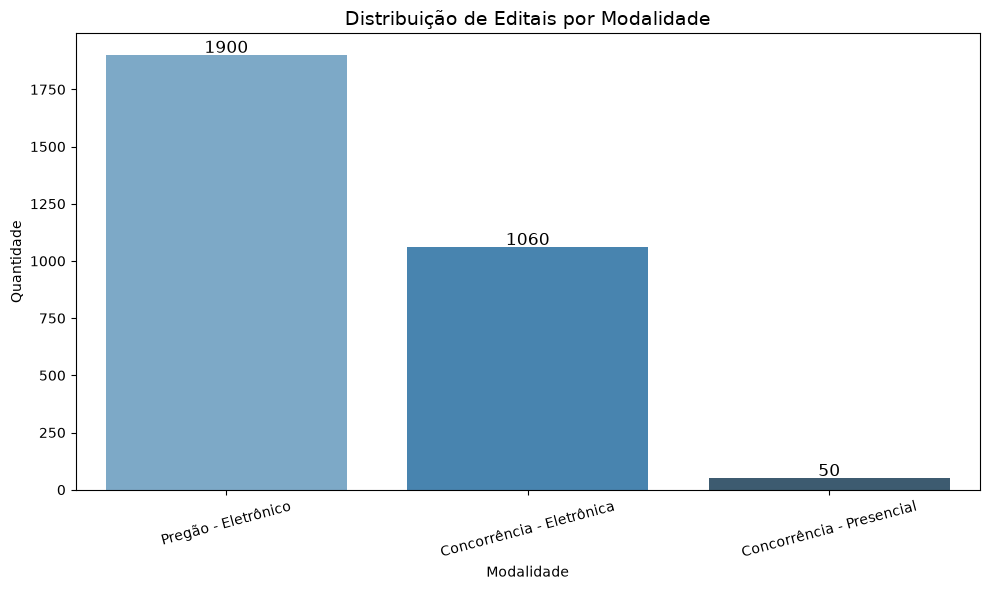

In [8]:
contagem_categorias = df["categoria"].value_counts().reset_index()
contagem_categorias.columns = ["categoria", "quantidade"]

plt.figure(figsize=(10, 6))
sns.barplot(data=contagem_categorias, x="categoria", y="quantidade", palette="Blues_d")

for i, row in contagem_categorias.iterrows():
    plt.text(i, row["quantidade"] + 10, str(row["quantidade"]), ha="center", fontsize=12)

plt.title("Distribuição de Editais por Modalidade", fontsize=14)
plt.xlabel("Modalidade")
plt.ylabel("Quantidade")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../dados/processed/plot_distribuicao_categorias.png", dpi=150)
plt.show()

### 4.2 Tamanho dos Textos

Analisar o comprimento do campo "objetoCompra"que será o texto principal a ser utilizado.

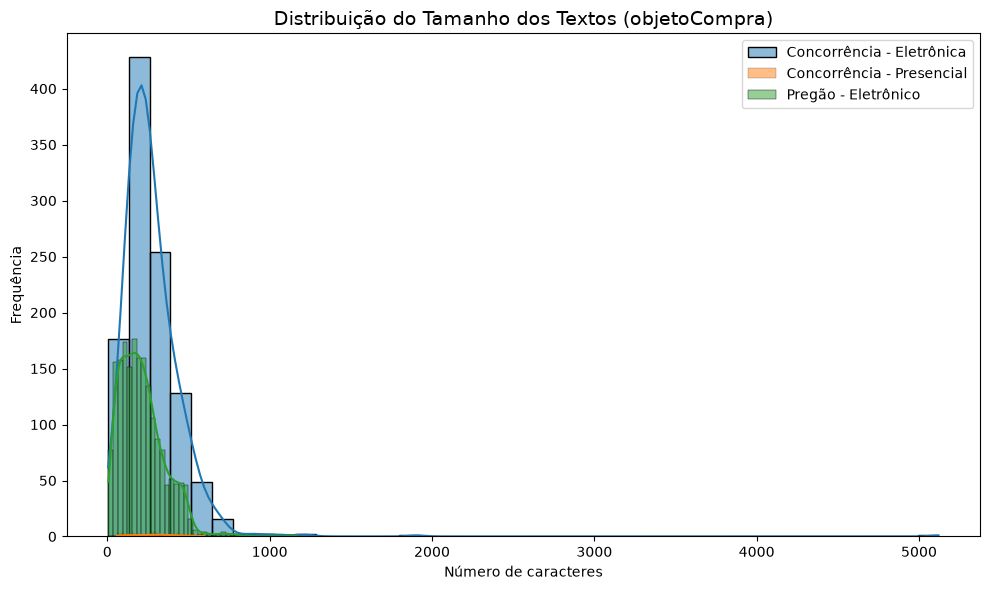

                            count    mean     std   min     25%    50%    75%  \
categoria                                                                       
Concorrência - Eletrônica  1060.0  274.28  219.58   5.0  163.00  238.0  343.0   
Concorrência - Presencial    50.0  288.74  147.56  59.0  164.25  294.0  391.0   
Pregão - Eletrônico        1900.0  214.40  139.00   7.0  108.75  192.0  288.0   

                              max  
categoria                          
Concorrência - Eletrônica  5120.0  
Concorrência - Presencial   596.0  
Pregão - Eletrônico        1164.0  


In [9]:
df["tamanho_objeto"] = df["objetoCompra"].fillna("").apply(len)

plt.figure(figsize=(10, 6))
for categoria, grupo in df.groupby("categoria"):
    sns.histplot(grupo["tamanho_objeto"], label=categoria, kde=True, alpha=0.5, bins=40)

plt.title("Distribuição do Tamanho dos Textos (objetoCompra)", fontsize=14)
plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.savefig("../dados/processed/plot_tamanho_textos.png", dpi=150)
plt.show()

print(df.groupby("categoria")["tamanho_objeto"].describe().round(2))

### 4.3 Nuvem de Palavras

Visualizar os termos mais frequentes nos objetos dos editais.

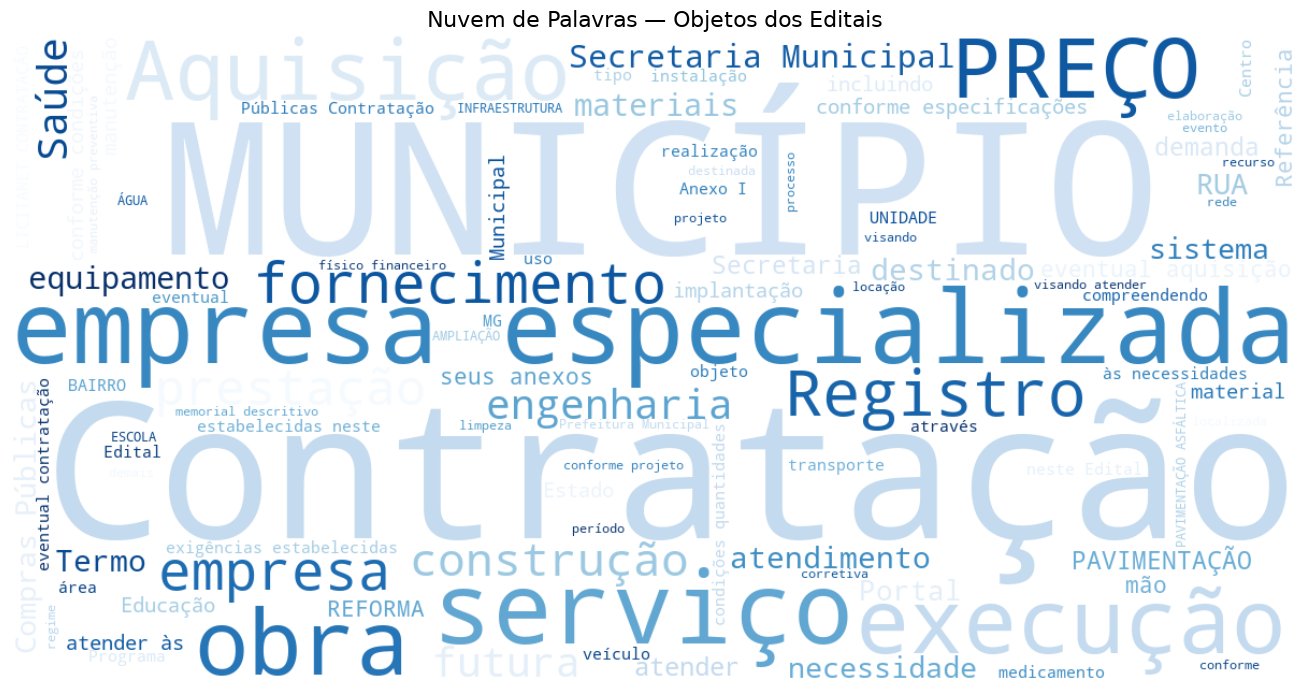

In [10]:
texto_completo = " ".join(df["objetoCompra"].fillna("").tolist())

stopwords_pt = {
    "de", "da", "do", "das", "dos", "e", "a", "o", "as", "os",
    "em", "para", "com", "por", "um", "uma", "no", "na", "nos",
    "nas", "ao", "aos", "ou", "que", "se", "não", "à", "pelo",
    "pela", "ser", "este", "esta", "esse", "essa", "the", "of"
}

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords_pt,
    max_words=100,
    colormap="Blues"
).generate(texto_completo)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras — Objetos dos Editais", fontsize=16)
plt.tight_layout()
plt.savefig("../dados/processed/wordcloud_editais.png", dpi=150)
plt.show()

### 4.4 Valor estimado por categoria

Analisar a distribuição de valores por modalidade, permitindo identificar qual modalidade concentra maior valor financeiro.

/var/folders/q5/15wlwks15xn36jck7ngtqcxm0000gn/T/ipykernel_49951/4293100772.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valor, x="categoria", y="valorTotalEstimado", palette="Set2")


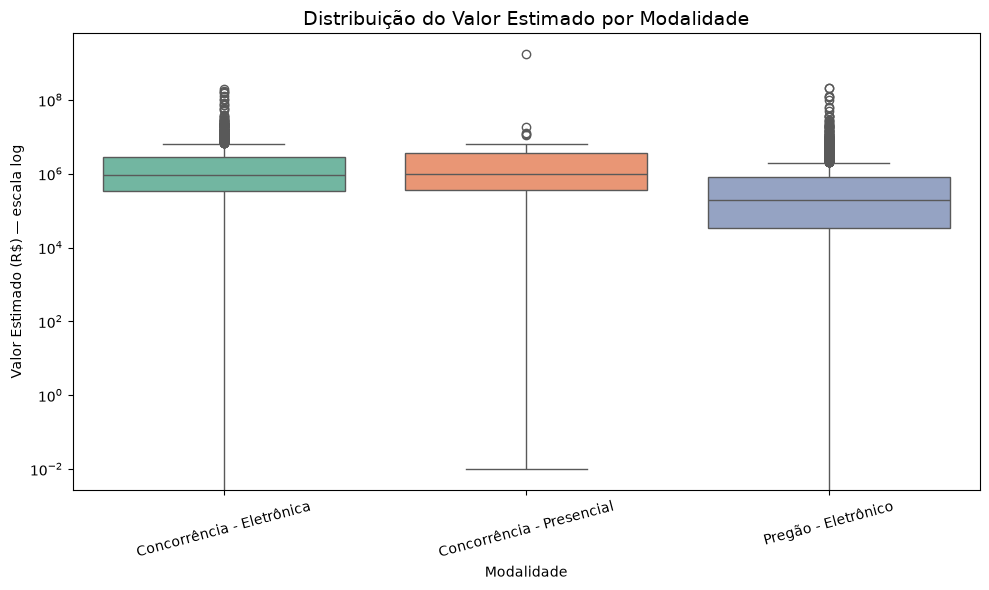

                            count         mean           std   min        25%  \
categoria                                                                       
Concorrência - Eletrônica  1060.0   4048387.27  1.381266e+07  0.00  345211.26   
Concorrência - Presencial    50.0  37371642.28  2.462210e+08  0.01  356280.03   
Pregão - Eletrônico        1900.0   1700701.01  9.392713e+06  0.00   33368.85   

                                 50%         75%           max  
categoria                                                       
Concorrência - Eletrônica  937290.51  2843762.30  1.975608e+08  
Concorrência - Presencial  970976.04  3532988.14  1.743399e+09  
Pregão - Eletrônico        200051.28   825047.84  2.113937e+08  


In [11]:
df_valor = df[df["valorTotalEstimado"].notna()].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_valor, x="categoria", y="valorTotalEstimado", palette="Set2")

plt.yscale("log")
plt.title("Distribuição do Valor Estimado por Modalidade", fontsize=14)
plt.xlabel("Modalidade")
plt.ylabel("Valor Estimado (R$) — escala log")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../dados/processed/plot_valor_estimado.png", dpi=150)
plt.show()

resumo = df_valor.groupby("categoria")["valorTotalEstimado"].describe().round(2)
print(resumo)

### 4.5 Visualização por Estado

Identificar os estados com maior volume de editais publicados.

/var/folders/q5/15wlwks15xn36jck7ngtqcxm0000gn/T/ipykernel_49951/85500775.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contagem_uf.head(10), x="uf", y="quantidade", palette="Blues_d")


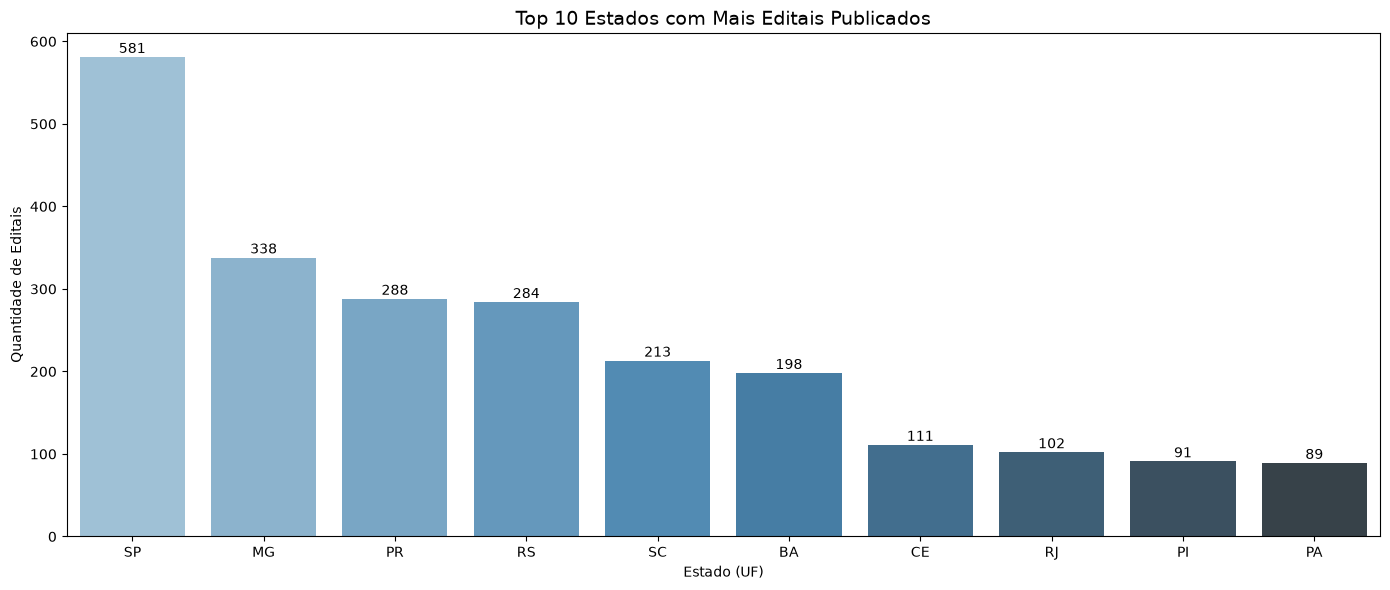

In [12]:
df["uf"] = df["unidadeOrgao"].apply(
    lambda x: x.get("ufSigla") if isinstance(x, dict) else None)

contagem_uf = df["uf"].value_counts().reset_index()
contagem_uf.columns = ["uf", "quantidade"]

plt.figure(figsize=(14, 6))
sns.barplot(data=contagem_uf.head(10), x="uf", y="quantidade", palette="Blues_d")

for i, row in contagem_uf.head(10).iterrows():
    plt.text(i, row["quantidade"] + 5, str(row["quantidade"]), ha="center", fontsize=10)

plt.title("Top 10 Estados com Mais Editais Publicados", fontsize=14)
plt.xlabel("Estado (UF)")
plt.ylabel("Quantidade de Editais")
plt.tight_layout()
plt.savefig("../dados/processed/plot_distribuicao_uf.png", dpi=150)
plt.show()

### 4.6 Órgãos Compradores

Identificar quais órgãos são os maiores compradores públicos.

/var/folders/q5/15wlwks15xn36jck7ngtqcxm0000gn/T/ipykernel_49951/3604975921.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_orgaos, x="quantidade", y="orgao", palette="Blues_d")


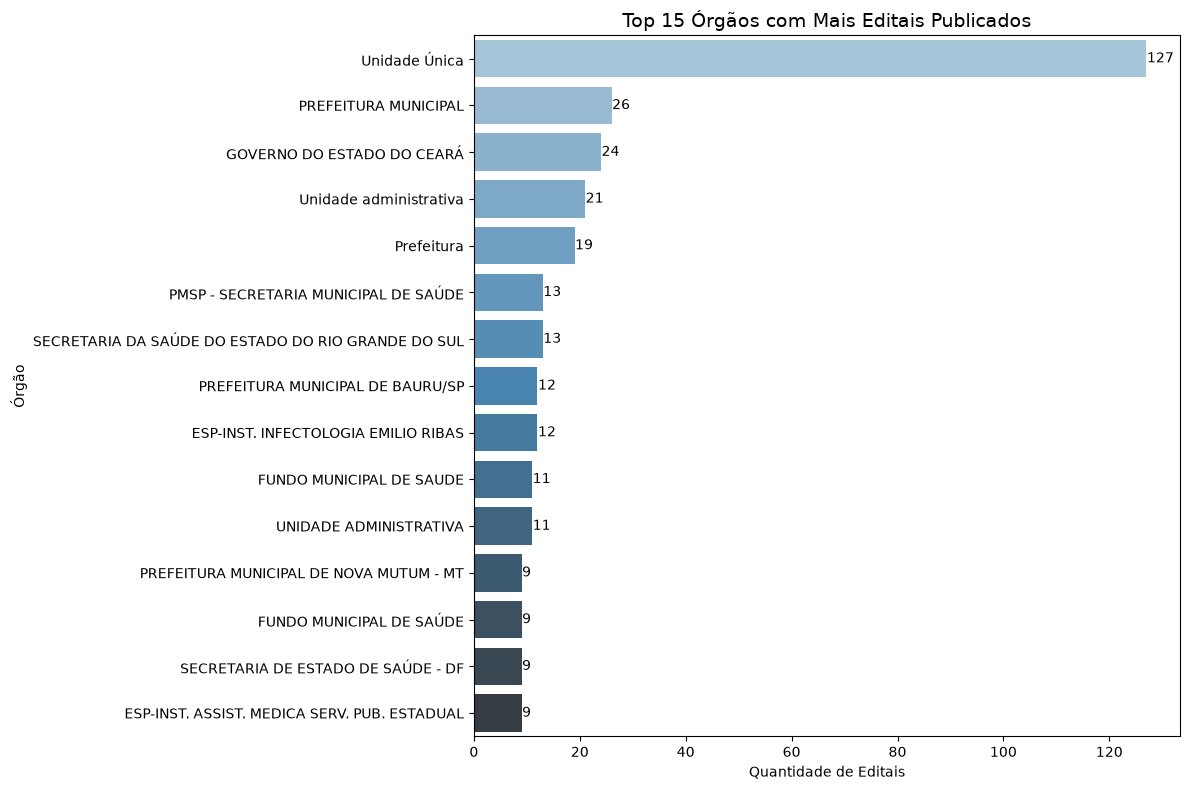

In [13]:
df["orgao"] = df["unidadeOrgao"].apply(
    lambda x: x.get("nomeUnidade") if isinstance(x, dict) else None
)

top_orgaos = df["orgao"].value_counts().head(15).reset_index()
top_orgaos.columns = ["orgao", "quantidade"]

plt.figure(figsize=(12, 8))
sns.barplot(data=top_orgaos, x="quantidade", y="orgao", palette="Blues_d")

for i, row in top_orgaos.iterrows():
    plt.text(row["quantidade"] + 0.1, i, str(row["quantidade"]), va="center", fontsize=10)

plt.title("Top 15 Órgãos com Mais Editais Publicados", fontsize=14)
plt.xlabel("Quantidade de Editais")
plt.ylabel("Órgão")
plt.tight_layout()
plt.savefig("../dados/processed/plot_top_orgaos.png", dpi=150)
plt.show()

### 4.7 Evolução

Analisar o volume de editais publicados por dia, separando por modalidade.

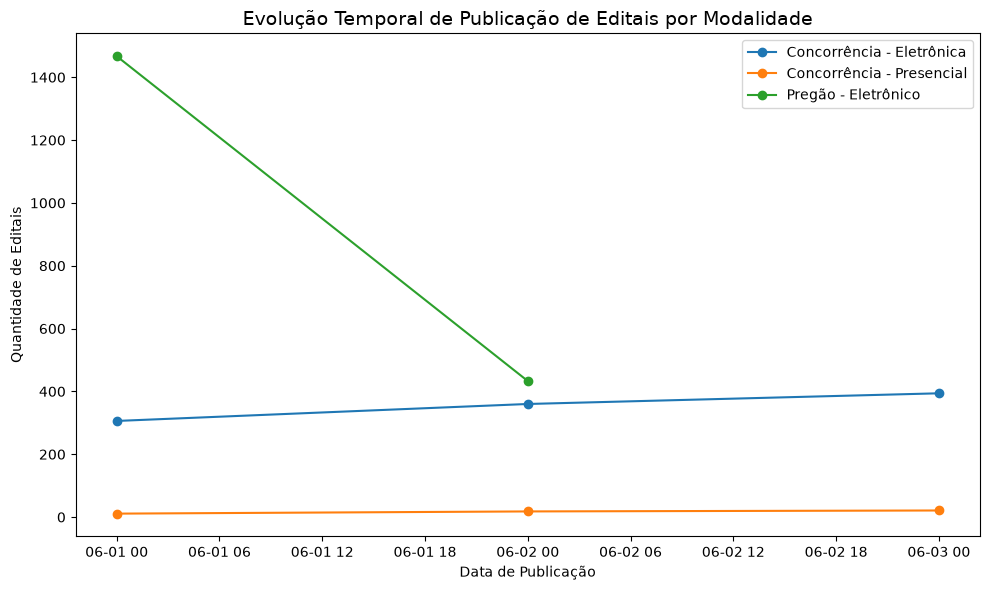

In [14]:
df["data_publicacao"] = pd.to_datetime(df["dataPublicacaoPncp"]).dt.date

evolucao = df.groupby(["data_publicacao", "categoria"]).size().reset_index()
evolucao.columns = ["data", "categoria", "quantidade"]

plt.figure(figsize=(10, 6))
for categoria, grupo in evolucao.groupby("categoria"):
    plt.plot(grupo["data"], grupo["quantidade"], marker="o", label=categoria)

plt.title("Evolução Temporal de Publicação de Editais por Modalidade", fontsize=14)
plt.xlabel("Data de Publicação")
plt.ylabel("Quantidade de Editais")
plt.legend()
plt.tight_layout()
plt.savefig("../dados/processed/plot_evolucao_temporal.png", dpi=150)
plt.show()

## 5. Pré-processamento Textual

In [9]:
nltk.download('stopwords')
stop_words = set(stopwords.words('portuguese'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tiagoleite/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# aplicando a função de limpeza na coluna que iremos utilizar
df['texto_limpo'] = df['objetoCompra'].apply(limparTexto)

# conferindo como ficou 
print('Texto original X texto limpo:\n')
for i in range(3):
    print(f'original: {df["objetoCompra"].iloc[i]}')
    print(f'Limpo:    {df["texto_limpo"].iloc[i]}')

Texto original X texto limpo:

original: CONTRATAÇÃO DE EMPRESA ESPECIALIZADA EM EXECUÇÃO DA OBRA DO ENTORNO DA ESCOLA QUE ESTA EM CONSTRUÇÃO, NO MUNICÍPIO DE ANDRÉ DA ROCHA/RS, COM RECURSOS PRÓPRIOS.
Limpo:    contratação empresa especializada execução obra entorno escola construção município andré rocha recursos próprios
original: [LICITANET] - CONTRATAÇÃO DE EMPRESA PARA REFORMA DO MATADOURO PÚBLICO MUNICIPAL DA PREFEITURA MUNICIPAL ZÉ DOA -MA
Limpo:    licitanet contratação empresa reforma matadouro público municipal prefeitura municipal doa
original: Contratação de empresa especializada para execução de obras de drenagem, redes de água, redes de esgotamento sanitário, pavimentação e urbanismo em ruas e travessas dos bairros Jardim Itaú Mirim e Jardim Recreio, conforme edital e seus anexos.
Limpo:    contratação empresa especializada execução obras drenagem redes água redes esgotamento sanitário pavimentação urbanismo ruas travessas bairros jardim itaú mirim jardim recreio conforme

In [11]:
# removendo 1 registro que estava em branco 
df = df[df["texto_limpo"] != ""].reset_index(drop=True)

print(f"Total após remoção de textos vazios: {len(df)}")
print(df["categoria"].value_counts())

Total após remoção de textos vazios: 3009
categoria
Pregão - Eletrônico          1899
Concorrência - Eletrônica    1060
Concorrência - Presencial      50
Name: count, dtype: int64


## 6. Divisão dos Dados

In [12]:


# separa treino (70%) e teste (30%)
df_filtrado = df[df['texto_limpo'] != '']

df_treino, df_teste = train_test_split(
    df_filtrado,
    test_size=0.30,
    random_state=42,
    stratify=df_filtrado['categoria']
)

# extrai X e y quando precisar
XTreino = df_treino['texto_limpo']
yTreino = df_treino['categoria']
XTeste  = df_teste['texto_limpo']
yTeste  = df_teste['categoria']



print("\nDistribuição Treino:")
print(yTreino.value_counts(normalize=True) * 100)

print("\nDistribuição Teste:")
print(yTeste.value_counts(normalize=True) * 100)


Distribuição Treino:
categoria
Pregão - Eletrônico          63.105413
Concorrência - Eletrônica    35.232669
Concorrência - Presencial     1.661918
Name: proportion, dtype: float64

Distribuição Teste:
categoria
Pregão - Eletrônico          63.122924
Concorrência - Eletrônica    35.215947
Concorrência - Presencial     1.661130
Name: proportion, dtype: float64


## 7. Embeddings

In [13]:
modeloEmbedding = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

/Users/tiagoleite/Desktop/projeto_nlp/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [14]:
# caminhos 
PROCESSED_PATH = Path("../dados/processed")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

# modelo
modelo = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("Gerando embeddings do treino...")
X_treino = modelo.encode(df_treino['texto_limpo'].tolist(), show_progress_bar=True)

print("Gerando embeddings do teste...")
X_teste = modelo.encode(df_teste['texto_limpo'].tolist(), show_progress_bar=True)

# labels
y_treino = df_treino['categoria'].values
y_teste  = df_teste['categoria'].values

# salvando no computador
np.save(PROCESSED_PATH / "X_treino.npy", X_treino)
np.save(PROCESSED_PATH / "X_teste.npy",  X_teste)

np.save(PROCESSED_PATH / "y_treino.npy", y_treino)
np.save(PROCESSED_PATH / "y_teste.npy",  y_teste)

print(f"\nEmbeddings salvos em {PROCESSED_PATH}")
print(f"Shape treino: {X_treino.shape}")

Gerando embeddings do treino...


Batches: 100%|██████████| 66/66 [00:10<00:00,  6.53it/s]


Gerando embeddings do teste...


Batches: 100%|██████████| 29/29 [00:03<00:00,  8.21it/s]


Embeddings salvos em ../dados/processed
Shape treino: (2106, 384)


### 7.1 Embeddings Salvos

In [15]:
# carregar uma vez so os embeddings salvos para serem usados e nao precisar criar toda vez 

X_treino = np.load(PROCESSED_PATH / "X_treino.npy")
X_teste  = np.load(PROCESSED_PATH / "X_teste.npy")

y_treino = np.load(PROCESSED_PATH / "y_treino.npy", allow_pickle=True)
y_teste  = np.load(PROCESSED_PATH / "y_teste.npy",  allow_pickle=True)

print("Embeddings carregados com sucesso.")

Embeddings carregados com sucesso.


## 8. Baseline - Logistic Regression


=== Logistic Regression — Validação ===

                           precision    recall  f1-score   support

Concorrência - Eletrônica       0.87      0.88      0.88       318
Concorrência - Presencial       1.00      0.07      0.12        15
      Pregão - Eletrônico       0.93      0.95      0.94       570

                 accuracy                           0.91       903
                macro avg       0.93      0.63      0.65       903
             weighted avg       0.91      0.91      0.90       903

F1 Macro (baseline): 0.6471


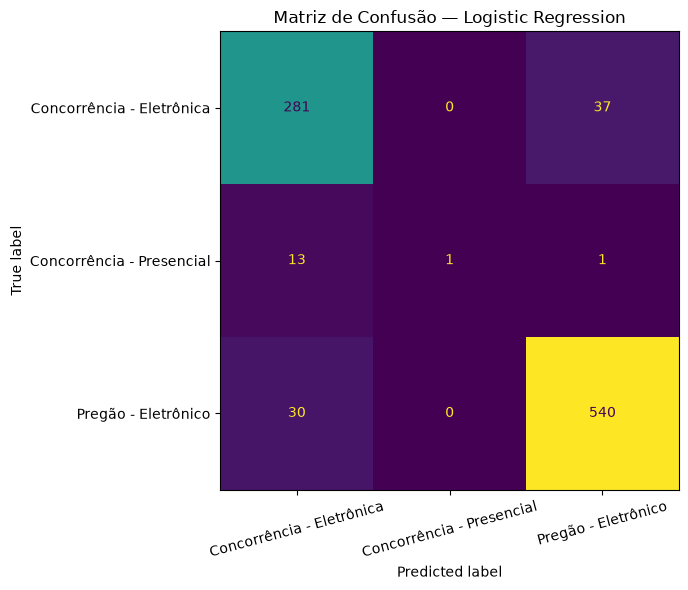

In [16]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_treino, y_treino)

y_pred_lr = lr.predict(X_teste)

print("=== Logistic Regression — Validação ===\n")
print(classification_report(y_teste, y_pred_lr))

f1_lr = f1_score(y_teste, y_pred_lr, average='macro')
print(f"F1 Macro (baseline): {f1_lr:.4f}")

# matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_teste, y_pred_lr,
    ax=ax,
    xticks_rotation=15,
    colorbar=False
)
ax.set_title("Matriz de Confusão — Logistic Regression")
plt.tight_layout()
plt.savefig(PROCESSED_PATH / "plot_cm_logistic_regression.png", dpi=150)
plt.show()

### 8.1 Comparativo com Linear SVM

=== Linear SVM — Validação ===

                           precision    recall  f1-score   support

Concorrência - Eletrônica       0.87      0.87      0.87       318
Concorrência - Presencial       0.00      0.00      0.00        15
      Pregão - Eletrônico       0.93      0.95      0.94       570

                 accuracy                           0.90       903
                macro avg       0.60      0.61      0.60       903
             weighted avg       0.89      0.90      0.90       903

F1 Macro (Linear SVM): 0.6020


/Users/tiagoleite/Desktop/projeto_nlp/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tiagoleite/Desktop/projeto_nlp/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tiagoleite/Desktop/projeto_nlp/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

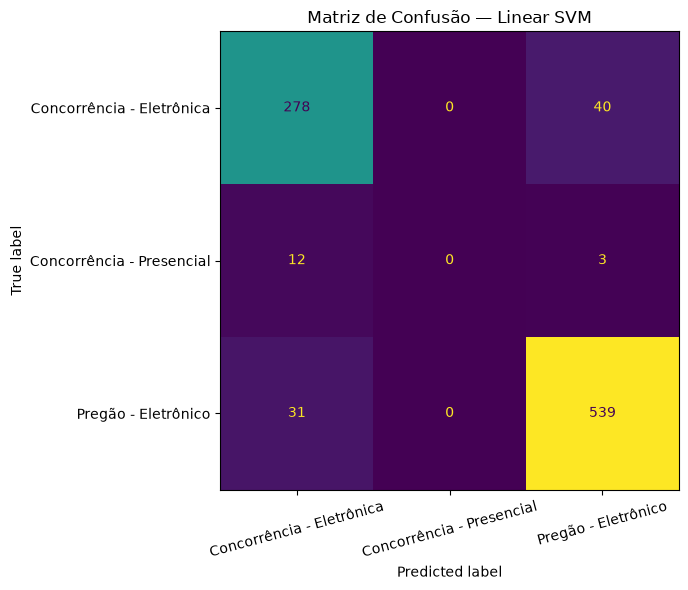

In [17]:
svm = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
svm.fit(X_treino, y_treino)

y_pred_svm = svm.predict(X_teste)

print("=== Linear SVM — Validação ===\n")
print(classification_report(y_teste, y_pred_svm))

f1_svm = f1_score(y_teste, y_pred_svm, average='macro')
print(f"F1 Macro (Linear SVM): {f1_svm:.4f}")

# matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_teste, y_pred_svm,
    ax=ax,
    xticks_rotation=15,
    colorbar=False
)
ax.set_title("Matriz de Confusão — Linear SVM")
plt.tight_layout()
plt.savefig(PROCESSED_PATH / "plot_cm_svm.png", dpi=150)
plt.show()

### 8.2 Tabela Comparativa - Teste

In [20]:
resultados = pd.DataFrame({'Modelo':['Logistic Regression', 'Linear SVM'],
                           'F1 Macro': [round(f1_lr, 4),       round(f1_svm, 4)],
                           'Conjunto': ['Teste',            'Teste']})

print(resultados.to_string(index=False))

             Modelo  F1 Macro Conjunto
Logistic Regression    0.6471    Teste
         Linear SVM    0.6020    Teste


## 9. Conclusões Modelagem

- O modelo funcionou?

    Sim. A Logistic Regression atingiu 91% de accuracy e F1 macro de 0.65 na validação. O resultado é sólido para as duas classes majoritárias (Pregão Eletrônico com F1 0.94 e Concorrência Eletrônica com F1 0.88), mas falhou na classe minoritária (Concorrência Presencial), que representa apenas 2% dos dados.

- Qual modelo foi melhor?

    Logistic Regression (F1 macro 0.6471) superou o Linear SVM (F1 macro 0.6020). A diferença principal foi na Concorrência Presencial — a LR ainda conseguiu recall de 7% nessa classe, enquanto o SVM não acertou nenhuma.

- Qual relevância para o projeto?

    A Logistic Regression será o baseline oficial para comparação com o LLM no Notebook 2. O F1 macro de 0.6471 é o número de referência — se o Gemini não superar esse valor, o LLM não se justifica para essa tarefa.

- O que o EDA contribui?

    Três contribuições diretas para as decisões técnicas:

    Confirmou o desbalanceamento natural (63% Pregão, 35% Concorrência Eletrônica, 2% Concorrência Presencial), justificando o uso de F1 macro em vez de accuracy
    Mostrou que objetoCompra tem textos curtos e consistentes, validando a escolha do MiniLM para embeddings
    Revelou os 3 insights gerenciais (volume vs valor, concentração geográfica, domínio do setor saúde) que vão alimentar o Dashboard do Streamlit

## 10. Salvando o dataset processado

In [21]:
df.to_parquet("../dados/processed/editais_processado.parquet", index=False)

print("DataFrame salvo em dados/processed/editais_processado.parquet")
print(f"Shape: {df.shape}")

DataFrame salvo em dados/processed/editais_processado.parquet
Shape: (3009, 38)
